#Abuse-Ring-Sentinel

##Graph based detection of coordinated fraud rings 
#Razorpay AI Buildathon — Track 02: AI Risk Manager

**Problem:**  Single transaction/single account models cant see fraud rings -> like if we see a row , by looking at the stats of row we cannot determine whether the account is suspicious , because it is related to other rows as wells , and like this there can be various realtions betweens rows which is very difficult to detect individually , so we need to have a different approach which can relate rows 

**Approach** Model accounts and the resources they touch the concept of graph, basically we can use graphs to model the account and resoureces of the system. Fraud rings show up as unusually dense , tightl-connected clusters -> communities in graph terms ,We detect them with community detection (Louvain), then score each community for
how "ring-like" it looks.

In [1]:
import pandas as pd 
import numpy as np
import random
from datetime import datetime ,timedelta

random.seed(42) ## To reproduce the same result for better evaluation
np.random.seed(42)



**The birthday problem and pigeon hole principle**
Suppose there are 23 people in a room , what are their chances of any two pairs birthday colligding ,You might initially think:
"23 is tiny compared with 365, so matching birthdays should be rare."
But we should not compare one person against one day we should compare pairs , eg for 23 its 253 , so there are 253 possibilites of collision which is significant 

pigeon hole principle : suppoose you have 5 holes and 6 pigeon and if we put all of then in the hole there is atleast one collision 

crux: 
basically we need to have large device_id pool for a set of people to avoid innocent pairing of individuals , so that normal people wont collide more ie they are not highlighted in our detection and fraudsters which have very much comman things get highlighted 

Hence , we are designing our dataset like this 

In [2]:
"""
    Normal users have their own(device , ip ,vpa) -> pools are large enought that 
    two random users never collide on some features like (upi id ), ip is deliberatly kept smaller 
    because overlap is comman (NAT , same cell tower , wifi router) 
    Therfore we have less weightage(less no) for the ip

"""

# Scaled up: target ~20,000 total accounts at a ~3% fraud rate (deliberately
# inflated above real-world fraud rates, which are usually <1%, specifically to
# get enough labeled ring INSTANCES for statistically meaningful cross-validation
# in a synthetic demo — documented in decisions.md).
NUM_NORMAL_ACCOUNTS = 19400

normal_devices = [f"dev_{i}" for i in range(400000)]
normal_ips     = [f"ip_{i}"  for i in range(65000)]
normal_vpas    = [f"vpa_{i}@upi" for i in range(400000)]

print(f"Pools ready: {len(normal_devices)} devices, {len(normal_ips)} ips, {len(normal_vpas)} vpas")

Pools ready: 400000 devices, 65000 ips, 400000 vpas


In [3]:
#Addresses

normal_addresses = [f"addr_{i}" for i in range(400000)]
print(f"Address pool ready: {len(normal_addresses)} addresses")

Address pool ready: 400000 addresses


In [4]:
#Randome time creation timestamp

def random_timestamp(start_days_ago=365, end_days_ago=1):
    """Random account creation date spread over the last year — normal accounts
    trickle in one at a time, unlike a fraud ring created in a tight burst."""
    days_ago = random.uniform(end_days_ago, start_days_ago)
    return datetime.now() - timedelta(days=days_ago)



In [5]:
#Generating 1000 normal accounts 

normal_accounts=[]

for i in range(NUM_NORMAL_ACCOUNTS):
    normal_accounts.append({
        "account_id" : f"acc_normal_{i}",
        "device_id" : random.choice(normal_devices),
        "ip_address": random.choice(normal_ips),
        "payout_vpa" :random.choice(normal_vpas),
        "address_id" :random.choice(normal_addresses),
        "created_at" : random_timestamp(),
        "is_ring_member": False,
        "ring_id" :None
    })


df_normal = pd.DataFrame(normal_accounts)
df_normal.head()

,account_id,device_id,ip_address,payout_vpa,address_id,created_at,is_ring_member,ring_id
0,acc_normal_0,dev_335243,ip_7296,vpa_13112@upi,addr_388786,2026-05-20 23:04:26.854036,False,None
1,acc_normal_1,dev_117026,ip_9144,vpa_386123@upi,addr_53736,2025-12-25 18:05:00.705373,False,None
2,acc_normal_2,dev_285929,ip_5697,vpa_309588@upi,addr_221208,2026-08-17 12:04:36.348407,False,None
3,acc_normal_3,dev_49123,ip_14328,vpa_121981@upi,addr_264951,2026-01-21 22:29:40.683914,False,None
4,acc_normal_4,dev_294254,ip_13031,vpa_375400@upi,addr_340726,2025-12-16 18:57:19.015627,False,None


In [6]:
def generate_promo_abuse_ring(ring_id , num_accounts=15,ring_devices_count=2):

    """
    Simulates : fraudsters creating many 'new' accounts to repeteadly claim a first
    order discount
    Signature : Heavy reuse of just a couple devices +counts created within a tight burst (a few hours) -unlike 
    normal accounts , which trickle in over months
    
    """

    ring_devices = [f"ring{ring_id}_dev_{i}" for i in range(ring_devices_count)]


    #all accounts creaeted within a 3 hour range 

    burst_start = datetime.now() -timedelta(days=random.randint(5,300))


    accounts =[]

    for i in range(num_accounts):
        accounts.append({
            "account_id": f"acc_ring{ring_id}_{i}",
            "device_id": random.choice(ring_devices),           # <- the signal: heavy device reuse
            "ip_address": random.choice(normal_ips),             # normal — not the signal here
            "payout_vpa": random.choice(normal_vpas),            # normal — not the signal here
            "address_id": random.choice(normal_addresses),       # normal — not the signal here
            "created_at": burst_start + timedelta(minutes=random.randint(0, 180)),  # <- the signal: tight burst
            "is_ring_member": True,
            "ring_id": f"promo_ring_{ring_id}"
        })

    return accounts

ring1_accounts = generate_promo_abuse_ring(ring_id=1)
df_ring1 = pd.DataFrame(ring1_accounts)



In [7]:
def generate_return_fraud_ring(ring_id, num_accounts=12, shared_address_count=2):
    """
    Simulates: a household/group repeatedly ordering and returning items
    using several 'different' accounts that all funnel back to the same 1-2
    addresses.
     Signature: shared address, otherwise normal-looking devices/IPs,
    timestamps spread out over months (not a burst — these can be older,
    dormant-looking accounts that only start returning things later).
    """
    ring_addresses = [f"ring{ring_id}_addr_{i}" for i in range(shared_address_count)]

    accounts = []
    for i in range(num_accounts):
        accounts.append({
            "account_id": f"acc_ring{ring_id}_{i}",
            "device_id": random.choice(normal_devices),        # normal — not the signal here
            "ip_address": random.choice(normal_ips),             # normal — not the signal here
            "payout_vpa": random.choice(normal_vpas),            # normal — not the signal here
            "address_id": random.choice(ring_addresses),         # <- the signal: shared address
            "created_at": random_timestamp(start_days_ago=200, end_days_ago=10),  # spread out, not a burst
            "is_ring_member": True,
            "ring_id": f"return_ring_{ring_id}"
        })
    return accounts

ring2_accounts = generate_return_fraud_ring(ring_id=2)
df_ring2 = pd.DataFrame(ring2_accounts)
df_ring2


,account_id,device_id,ip_address,payout_vpa,address_id,created_at,is_ring_member,ring_id
0,acc_ring2_0,dev_257447,ip_43044,vpa_236275@upi,ring2_addr_0,2026-03-17 05:08:02.235115,True,return_ring_2
1,acc_ring2_1,dev_120067,ip_22151,vpa_345641@upi,ring2_addr_1,2026-03-11 10:05:16.841199,True,return_ring_2
2,acc_ring2_2,dev_251539,ip_8657,vpa_241896@upi,ring2_addr_1,2026-02-20 08:41:45.142531,True,return_ring_2
3,acc_ring2_3,dev_288076,ip_19433,vpa_238742@upi,ring2_addr_0,2026-05-23 07:22:14.604221,True,return_ring_2
4,acc_ring2_4,dev_185229,ip_37949,vpa_313931@upi,ring2_addr_1,2026-02-25 11:14:22.194022,True,return_ring_2
5,acc_ring2_5,dev_145865,ip_24764,vpa_51708@upi,ring2_addr_1,2026-07-08 13:36:50.835711,True,return_ring_2
6,acc_ring2_6,dev_118772,ip_26309,vpa_29390@upi,ring2_addr_1,2026-04-07 20:40:47.814361,True,return_ring_2
7,acc_ring2_7,dev_150452,ip_61881,vpa_152394@upi,ring2_addr_1,2026-04-02 15:37:06.417769,True,return_ring_2
8,acc_ring2_8,dev_1418,ip_27671,vpa_379293@upi,ring2_addr_1,2026-06-22 16:19:31.173535,True,return_ring_2
9,acc_ring2_9,dev_319134,ip_48523,vpa_33255@upi,ring2_addr_0,2026-06-07 19:18:28.705460,True,return_ring_2


In [8]:
def generate_money_mule_ring(ring_id, num_accounts=18, shared_vpa_count=1):
    """
    Simulates: a mule network where fraud proceeds get funneled to a small set
    of payout VPAs
    Signature: ONLY the payout VPA is shared — devices, IPs,
    addresses, and timing all look completely normal and unrelated. Hardest
    pattern to catch, since almost nothing else overlaps.
    """
    ring_vpas = [f"ring{ring_id}_mule_vpa_{i}@upi" for i in range(shared_vpa_count)]

    accounts = []
    for i in range(num_accounts):
        accounts.append({
            "account_id": f"acc_ring{ring_id}_{i}",
            "device_id": random.choice(normal_devices),        # normal — not the signal here
            "ip_address": random.choice(normal_ips),             # normal — not the signal here
            "payout_vpa": random.choice(ring_vpas),              # <- the signal: shared payout destination
            "address_id": random.choice(normal_addresses),       # normal — not the signal here
            "created_at": random_timestamp(),                    # normal spread, no burst
            "is_ring_member": True,
            "ring_id": f"mule_ring_{ring_id}"
        })
    return accounts

ring3_accounts = generate_money_mule_ring(ring_id=3)
df_ring3 = pd.DataFrame(ring3_accounts)
df_ring3


,account_id,device_id,ip_address,payout_vpa,address_id,created_at,is_ring_member,ring_id
0,acc_ring3_0,dev_56423,ip_1695,ring3_mule_vpa_0@upi,addr_155334,2026-02-24 21:56:32.165339,True,mule_ring_3
1,acc_ring3_1,dev_75922,ip_50889,ring3_mule_vpa_0@upi,addr_75988,2025-09-18 09:45:35.185533,True,mule_ring_3
2,acc_ring3_2,dev_352963,ip_49426,ring3_mule_vpa_0@upi,addr_295257,2026-01-14 21:42:24.438225,True,mule_ring_3
3,acc_ring3_3,dev_328787,ip_59181,ring3_mule_vpa_0@upi,addr_32484,2025-11-20 12:15:06.845412,True,mule_ring_3
4,acc_ring3_4,dev_280760,ip_61276,ring3_mule_vpa_0@upi,addr_149230,2026-02-18 22:30:39.372643,True,mule_ring_3
5,acc_ring3_5,dev_283668,ip_41661,ring3_mule_vpa_0@upi,addr_203108,2025-12-22 03:42:23.006466,True,mule_ring_3
6,acc_ring3_6,dev_172473,ip_17179,ring3_mule_vpa_0@upi,addr_366812,2026-08-04 06:48:08.053612,True,mule_ring_3
7,acc_ring3_7,dev_145388,ip_46955,ring3_mule_vpa_0@upi,addr_75737,2026-01-23 04:50:08.144455,True,mule_ring_3
8,acc_ring3_8,dev_30998,ip_27819,ring3_mule_vpa_0@upi,addr_130894,2025-11-15 18:14:55.736536,True,mule_ring_3
9,acc_ring3_9,dev_95000,ip_51390,ring3_mule_vpa_0@upi,addr_248513,2025-12-12 22:31:45.365150,True,mule_ring_3


In [9]:
def generate_legit_overlap_cluster(cluster_id , num_accounts =4 , overlap_type="address"):
    """ 
        Simulates innocent real world overlap : a family sharing one home address
        or small office sharing one devide/ wifi , which are obviously not fraud but still
        looks a ring like struture , In real world these scenario exists 
    """

    shared_device = f"legit{cluster_id}_dev_0"
    shared_address = f"legit{cluster_id}_addr_0"
    accounts =[]

    for i in range(num_accounts):
        accounts.append({
            "account_id" : f"acc_legit{cluster_id}_{i}",
            "device_id" : shared_device if overlap_type=="device" else random.choice(normal_devices),
            "ip_address" : random.choice(normal_ips),
            "payout_vpa" : random.choice(normal_vpas),
            "address_id" : shared_address if overlap_type=="address" else random.choice(normal_addresses),
            "created_at" : random_timestamp(),
            "is_ring_member" :False,
            "ring_id" : f"legit_cluster_{cluster_id}"

        })

    return accounts

legit1_accounts = generate_legit_overlap_cluster(cluster_id=1, num_accounts=4, overlap_type="address")  # family
legit2_accounts = generate_legit_overlap_cluster(cluster_id=2, num_accounts=3, overlap_type="device")   # small office
df_legit1 = pd.DataFrame(legit1_accounts)
df_legit2 = pd.DataFrame(legit2_accounts)


print(f"Legit clusters: {len(df_legit1)} sharing address, {len(df_legit2)} sharing device — both is_ring_member=False")
    

Legit clusters: 4 sharing address, 3 sharing device — both is_ring_member=False


In [10]:
""" 
 Giving second instances of each ring so as to make classifier learn 

"""

ring4_accounts = generate_promo_abuse_ring(ring_id=4 , num_accounts=10 , ring_devices_count=1)
df_ring4 = pd.DataFrame(ring4_accounts)

ring5_accounts = generate_return_fraud_ring(ring_id=5,num_accounts=8, shared_address_count=1)
df_ring5 = pd.DataFrame(ring5_accounts)

ring6_accounts = generate_money_mule_ring(ring_id=6,num_accounts=10,shared_vpa_count=1)
df_ring6 = pd.DataFrame(ring6_accounts)


print(f"promo: {len(df_ring1)}+{len(df_ring4)}, return: {len(df_ring2)}+{len(df_ring5)}, mule: {len(df_ring3)}+{len(df_ring6)}")

promo: 15+10, return: 12+8, mule: 18+10


In [11]:
# Bulk-generate more ring instances: 13 more of each pattern, so combined with
# ring1/ring4, ring2/ring5, ring3/ring6 we have 15 instances per pattern (45
# total) instead of 2 — enough independent ring-level examples for real
# statistical power (cross-validation) instead of just 2-3 held-out examples.
# ring_id must stay globally unique across ALL types (it's used to build
# account_id and resource names), so we use one shared counter, not per-type.
bulk_ring_dfs = []
next_id = 7
for i in range(13):
    bulk_ring_dfs.append(pd.DataFrame(generate_promo_abuse_ring(
        ring_id=next_id, num_accounts=random.randint(8, 18), ring_devices_count=random.choice([1, 2])
    )))
    next_id += 1

    bulk_ring_dfs.append(pd.DataFrame(generate_return_fraud_ring(
        ring_id=next_id, num_accounts=random.randint(6, 16), shared_address_count=random.choice([1, 2])
    )))
    next_id += 1

    bulk_ring_dfs.append(pd.DataFrame(generate_money_mule_ring(
        ring_id=next_id, num_accounts=random.randint(8, 20), shared_vpa_count=1
    )))
    next_id += 1

# 8 more legit clusters (legit1, legit2 already exist) — more real hard-negative
# variety for the classifier, on top of pure accidental noise.
bulk_legit_dfs = []
for cid in range(3, 11):
    bulk_legit_dfs.append(pd.DataFrame(generate_legit_overlap_cluster(
        cluster_id=cid, num_accounts=random.randint(3, 6),
        overlap_type=random.choice(["address", "device"])
    )))

print(f"Generated {len(bulk_ring_dfs)} more ring instances ({sum(len(d) for d in bulk_ring_dfs)} accounts)")
print(f"Generated {len(bulk_legit_dfs)} more legit clusters ({sum(len(d) for d in bulk_legit_dfs)} accounts)")

Generated 39 more ring instances (434 accounts)
Generated 8 more legit clusters (39 accounts)


In [12]:
#Now concatinating all the dataframes 

df_normal["ring_id"] = None
df_all = pd.concat(
    [df_normal, df_ring1, df_ring4, df_ring2, df_ring5, df_ring3, df_ring6, df_legit1, df_legit2]
    + bulk_ring_dfs + bulk_legit_dfs,
    ignore_index=True
)

print(f"Total accounts: {len(df_all)}")
print(f"Ring members: {df_all['is_ring_member'].sum()}")
print(f"Fraud rate: {df_all['is_ring_member'].sum() / len(df_all):.1%}")
print(df_all['ring_id'].value_counts(dropna=False).head(20))

Total accounts: 19953
Ring members: 507
Fraud rate: 2.5%
ring_id
None              19400
mule_ring_21         20
promo_ring_13        18
mule_ring_3          18
mule_ring_36         16
mule_ring_39         15
mule_ring_12         15
return_ring_32       15
return_ring_20       15
promo_ring_1         15
promo_ring_40        14
mule_ring_33         14
promo_ring_31        14
mule_ring_42         13
promo_ring_10        13
mule_ring_15         13
promo_ring_37        13
promo_ring_19        12
mule_ring_18         12
return_ring_11       12
Name: count, dtype: int64


In [13]:
import networkx as nx 
from itertools import combinations
from collections import defaultdict

""" 
 We cannot use networkx's built in bipartite projection because it cannot express 
 a shared vpa is a stronger signal than a shared IP . We want that ip is a comman things 
 in which we can trap innocent people ,vpa overlap is suspicious

 Also we are going to use bipartate graph because we mainly have two categories , one : people two : rescourss , 
 we cannot tie people and people  directly but we can surely track people and resources which in later will help
 our algo to tie of people and people 

"""

RESOURCE_WEIGHTS = {
    "device_id" : 3 ,
    "ip_address" : 1 ,
    "payout_vpa" : 5,
    "address_id" : 4 
}

edge_weight = defaultdict(int)
for col ,w in RESOURCE_WEIGHTS.items():
    groups = df_all.groupby(col)["account_id"].apply(list)

    for accounts in groups:
        if len(accounts) <2:
            continue # No body else shared this 
        for a , b in combinations(sorted(accounts) ,2):
            edge_weight[(a,b)]+=w

G = nx.Graph()

G.add_nodes_from(df_all["account_id"])
for (a,b) , w in edge_weight.items():
    G.add_edge(a,b,weight=w)


print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Isolated accounts (share nothing with anyone): {nx.number_of_isolates(G)}")








Graph: 19953 nodes, 6800 edges
Isolated accounts (share nothing with anyone): 12423


In [14]:
# A known promo-ring member should connect almost entirely to its own ring
# (via shared device). A random normal account should mostly be isolated,
# or have at most a weak accidental edge or two.
for probe in ["acc_ring1_8", "acc_normal_0"]:
    if probe not in G or G.degree(probe) == 0:
        print(f"{probe}: isolated (0 neighbors)\n")
        continue
    neighbors = sorted(G[probe].items(), key=lambda kv: -kv[1]["weight"])
    print(f"{probe} ({len(neighbors)} neighbors):")
    for n, data in neighbors[:6]:
        print(f"   {n:20s} weight={data['weight']}")
    print()


acc_ring1_8 (10 neighbors):
   acc_ring1_1          weight=3
   acc_ring1_10         weight=3
   acc_ring1_11         weight=3
   acc_ring1_13         weight=3
   acc_ring1_14         weight=3
   acc_ring1_2          weight=3

acc_normal_0: isolated (0 neighbors)



In [15]:
communities = nx.algorithms.community.louvain_communities(G , weight="weight" , seed=42, resolution=1.3)
# resolution=1.3 chosen after experimentation: it recovers legit_cluster_2 as its
# own community without breaking anything else. return_ring_5 still doesn't
# separate out at this or higher resolution (tried 1.6 too) — documented as a
# known limitation in decisions.md rather than force-fit further.

print(f"louvain found {len(communities)} communities")

non_trivial = [c for c in communities if len(c)>=3]

print(f"communities with >=3 members : {len(non_trivial)}")

for c in sorted(non_trivial, key=len , reverse=True):
    print(f"   size={len(c)}")

louvain found 15332 communities
communities with >=3 members : 757
   size=31
   size=30
   size=27
   size=27
   size=26
   size=23
   size=23
   size=21
   size=21
   size=19
   size=19
   size=18
   size=17
   size=16
   size=16
   size=16
   size=15
   size=14
   size=13
   size=13
   size=13
   size=12
   size=12
   size=12
   size=12
   size=12
   size=11
   size=11
   size=10
   size=10
   size=10
   size=9
   size=9
   size=9
   size=9
   size=9
   size=9
   size=9
   size=8
   size=8
   size=8
   size=8
   size=8
   size=8
   size=8
   size=8
   size=7
   size=7
   size=7
   size=7
   size=7
   size=7
   size=7
   size=7
   size=7
   size=7
   size=7
   size=7
   size=7
   size=7
   size=7
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
   size=6
  

In [16]:
# For each non-trivial community, what ground-truth label (ring_id) dominates it?
# A clean recovery = each planted ring lands in its own community at high purity.
acc_to_ring = df_all.set_index("account_id")["ring_id"].to_dict()

print(f"{'size':>4}  {'dominant label':<16}  {'purity':>7}")
for c in sorted(non_trivial, key=len, reverse=True):
    labels = [acc_to_ring[a] for a in c]
    dominant = max(set(labels), key=labels.count)
    purity = labels.count(dominant) / len(labels)
    print(f"{len(c):>4}  {str(dominant):<16}  {purity:>6.0%}")


size  dominant label     purity
  31  mule_ring_21         65%
  30  None                 60%
  27  mule_ring_3          67%
  27  mule_ring_12         56%
  26  promo_ring_13        69%
  23  None                 65%
  23  mule_ring_39         65%
  21  mule_ring_33         67%
  21  mule_ring_36         76%
  19  promo_ring_40        74%
  19  mule_ring_42         68%
  18  promo_ring_1         61%
  17  mule_ring_15         76%
  16  None                 50%
  16  mule_ring_6          62%
  16  promo_ring_31        62%
  15  mule_ring_30         67%
  14  promo_ring_34        71%
  13  promo_ring_4         77%
  13  return_ring_11       69%
  13  mule_ring_27         69%
  12  None                 50%
  12  promo_ring_37        58%
  12  mule_ring_24         67%
  12  return_ring_32       83%
  12  None                 50%
  11  return_ring_2        82%
  11  return_ring_8        64%
  10  legit_cluster_6      60%
  10  return_ring_20       90%
  10  promo_ring_28        90%
   9  N

In [17]:
!pip install plotly



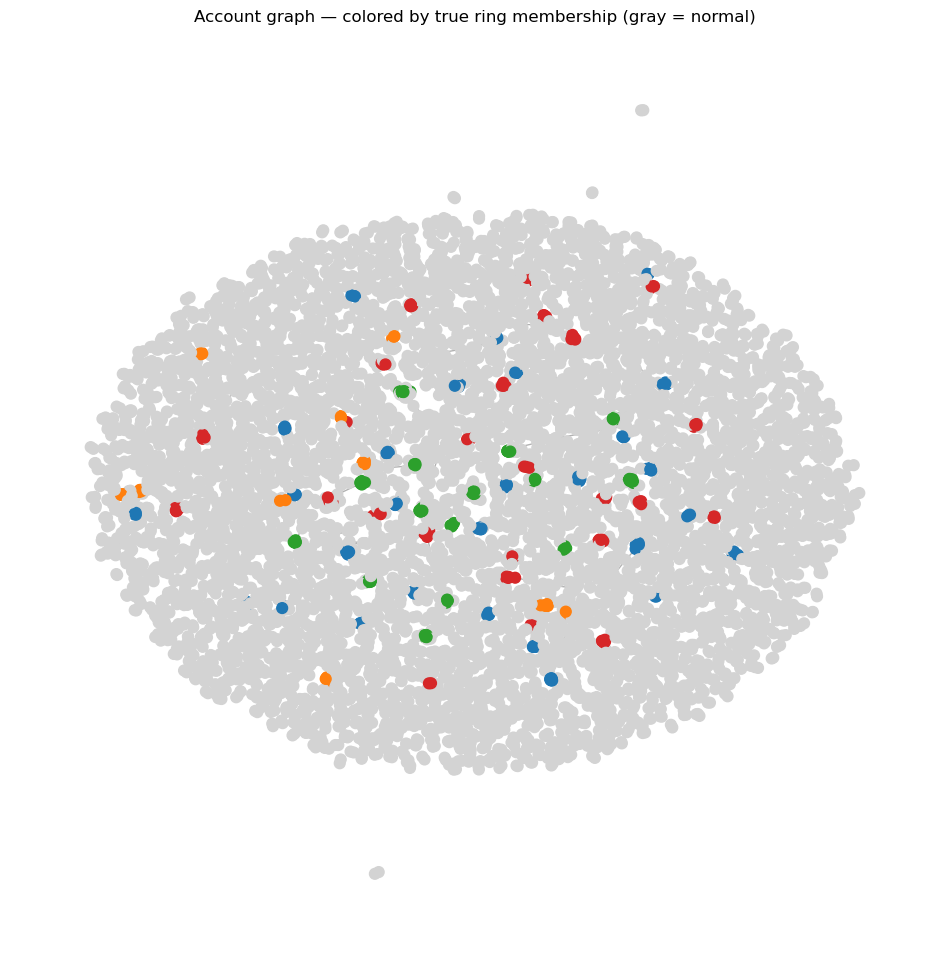

In [18]:
import matplotlib.pyplot as plt

# Only plot accounts that actually have at least one edge — the isolated
# accounts would just be lonely dots cluttering the plot and telling us nothing.
connected_nodes = [n for n in G.nodes if G.degree(n) > 0]
subG = G.subgraph(connected_nodes)

# Color by ground-truth ring_id — remember, this is only for OUR eyes to verify
# the pipeline worked; Louvain itself never sees this column. Matched by prefix
# instead of an exact dict so it keeps working if more ring instances are added.
def ring_color(ring_id):
    if ring_id is None:
        return "lightgray"
    if ring_id.startswith("promo_ring"):
        return "tab:red"
    if ring_id.startswith("return_ring"):
        return "tab:blue"
    if ring_id.startswith("mule_ring"):
        return "tab:green"
    if ring_id.startswith("legit_cluster"):
        return "tab:orange"
    return "black"  # shouldn't happen — flags anything unexpected

node_colors = [ring_color(acc_to_ring[n]) for n in subG.nodes]

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(subG, weight="weight", seed=42, k=0.3)
nx.draw_networkx_nodes(subG, pos, node_color=node_colors, node_size=60)
nx.draw_networkx_edges(subG, pos, alpha=0.3)
plt.title("Account graph — colored by true ring membership (gray = normal)")
plt.axis("off")
plt.show()

In [19]:
import plotly.graph_objects as go

# Same idea as before — only plot connected accounts, position them with a
# 3D force-directed layout (edges = springs pulling related accounts together).
pos_3d = nx.spring_layout(subG, weight="weight", seed=42, dim=3, k=0.3)

# Matched by prefix instead of an exact dict so it keeps working if more ring
# instances get added later.
def ring_color(ring_id):
    if ring_id is None:
        return "lightgray"
    if ring_id.startswith("promo_ring"):
        return "red"
    if ring_id.startswith("return_ring"):
        return "blue"
    if ring_id.startswith("mule_ring"):
        return "green"
    if ring_id.startswith("legit_cluster"):
        return "orange"
    return "black"  # shouldn't happen — flags anything unexpected

# Build the edge lines: Plotly draws one continuous line per trace, so we
# insert None between each edge's two endpoints to "lift the pen" and stop
# it from drawing a line connecting unrelated edges together.
edge_x, edge_y, edge_z = [], [], []
for a, b in subG.edges():
    x0, y0, z0 = pos_3d[a]
    x1, y1, z1 = pos_3d[b]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_z += [z0, z1, None]

edge_trace = go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode="lines",
    line=dict(color="lightgray", width=1),
    hoverinfo="none",
)

node_x = [pos_3d[n][0] for n in subG.nodes]
node_y = [pos_3d[n][1] for n in subG.nodes]
node_z = [pos_3d[n][2] for n in subG.nodes]
node_colors = [ring_color(acc_to_ring[n]) for n in subG.nodes]
node_text = [f"{n}<br>ring: {acc_to_ring[n]}<br>degree: {subG.degree(n)}" for n in subG.nodes]

node_trace = go.Scatter3d(
    x=node_x, y=node_y, z=node_z,
    mode="markers",
    marker=dict(size=5, color=node_colors),
    text=node_text,
    hoverinfo="text",
)

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(
    title="Account graph in 3D — colored by true ring membership (gray = normal)",
    showlegend=False,
    scene=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False)),
    margin=dict(l=0, r=0, b=0, t=40),
)
fig.show()

In [20]:
# Turning every non-trivial community into one row of engineered features + a label
# This we are trying to build a ml dataset - one example per community , not per account 


acc_to_time = df_all.set_index("account_id")["created_at"]


def community_features(members):
    subG = G.subgraph(members) # This gets us all the edges among all the accounts of community members 
    size = len(members)

    max_possible_edges = size* (size-1) /2 

    num_edges = subG.number_of_edges()

    density = num_edges / max_possible_edges if max_possible_edges >0 else 0 

    # means what fraction of all possible pairs in the groups are actually connected 
    # a tight ring where most of the members are conncected has high density


    weights = [d['weight'] for _ , _, d in subG.edges(data=True)]

    avg_weight  = np.mean(weights) if weights else 0

    max_weight = max(weights) if weights else 0 

    timestamps = acc_to_time.loc[list(members)]

    timestamp_std_hours = timestamps.std().total_seconds() / 3600


    return {
        "size": size ,
        "density" : density ,
        "avg_weight" : avg_weight,
        "max_weight" : max_weight ,
        "timestamp_std_hours" : timestamp_std_hours
    }


RING_PREFIXES = ("promo_ring", "return_ring", "mule_ring")


rows = []

for c in non_trivial:
    labels = [acc_to_ring[a] for a in c ] # collect all the labesls od members 
    dominant = max(set(labels) , key=labels.count) # get the dominat label 

    is_ring = 1 if (dominant is not None and dominant.startswith(RING_PREFIXES)) else 0
    # assign it 1 if either of them is suspect ie in our prefix else 0 


    feats = community_features(c)
    feats["is_ring"] = is_ring
    feats["dominant_label"] = dominant # just to see 
    rows.append(feats)


df_communities = pd.DataFrame(rows)
print(df_communities.shape)
print(df_communities["is_ring"].value_counts())
df_communities.sort_values("is_ring", ascending=False)





(757, 7)
is_ring
0    698
1     59
Name: count, dtype: int64


,size,density,avg_weight,max_weight,timestamp_std_hours,is_ring,dominant_label
710,4,1.000000,4.000000,4,1349.407368,1,return_ring_14
724,6,0.733333,2.818182,3,2443.943616,1,promo_ring_25
722,9,0.638889,3.739130,4,1432.658542,1,return_ring_23
721,4,0.666667,4.250000,5,625.668746,1,return_ring_23
519,12,0.424242,2.642857,5,1926.181633,1,promo_ring_37
...,...,...,...,...,...,...,...
254,3,0.666667,2.500000,4,2900.989221,0,None
255,6,0.400000,2.000000,4,3357.357467,0,None
256,4,0.500000,3.000000,5,1818.455987,0,None
257,3,0.666667,3.000000,5,1826.839615,0,None


In [21]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# With only 2-3 held-out examples, one train/test split isn't statistically
# meaningful (a single lucky/unlucky example swings the number wildly). With 45
# ring instances now available, switch to 5-fold cross-validation instead, and
# report mean +/- spread across folds rather than one point estimate.
#
# Group by underlying ring identity so fragments of the SAME ring (which can
# still occasionally split across two communities, same as before) never leak
# across train/test within a fold. Each independent noise community gets its
# own unique group, since noise communities are unrelated to each other and
# should be free to land in any fold.
df_communities["group"] = [
    label if label is not None else f"noise_{i}"
    for i, label in zip(df_communities.index, df_communities["dominant_label"])
]

FEATURES = ["size", "density", "avg_weight", "max_weight", "timestamp_std_hours"]
X = df_communities[FEATURES]
y = df_communities["is_ring"]
groups = df_communities["group"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

precisions, recalls, f1s = [], [], []
for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups)):
    clf = RandomForestClassifier(n_estimators=50, max_depth=4, class_weight="balanced", random_state=42)
    clf.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred = clf.predict(X.iloc[test_idx])

    p = precision_score(y.iloc[test_idx], y_pred, zero_division=0)
    r = recall_score(y.iloc[test_idx], y_pred, zero_division=0)
    f = f1_score(y.iloc[test_idx], y_pred, zero_division=0)
    precisions.append(p); recalls.append(r); f1s.append(f)

    n_pos = y.iloc[test_idx].sum()
    print(f"Fold {fold}: precision={p:.2f} recall={r:.2f} f1={f:.2f} (test size={len(test_idx)}, positives={n_pos})")

print(f"\nMean precision: {np.mean(precisions):.2f} +/- {np.std(precisions):.2f}")
print(f"Mean recall:    {np.mean(recalls):.2f} +/- {np.std(recalls):.2f}")
print(f"Mean F1:        {np.mean(f1s):.2f} +/- {np.std(f1s):.2f}")

# Final model fit on ALL data, purely for interpretability (feature importances)
# — not used for the reported metrics above, which come only from held-out folds.
final_clf = RandomForestClassifier(n_estimators=50, max_depth=4, class_weight="balanced", random_state=42)
final_clf.fit(X, y)
print("\nFeature importances (final model, fit on all data):")
for feat, imp in sorted(zip(FEATURES, final_clf.feature_importances_), key=lambda x: -x[1]):
    print(f"  {feat:20s} {imp:.3f}")

Fold 0: precision=0.82 recall=0.75 f1=0.78 (test size=152, positives=12)
Fold 1: precision=0.79 recall=0.92 f1=0.85 (test size=152, positives=12)
Fold 2: precision=0.77 recall=0.83 f1=0.80 (test size=151, positives=12)
Fold 3: precision=0.85 recall=0.92 f1=0.88 (test size=151, positives=12)
Fold 4: precision=0.90 recall=0.82 f1=0.86 (test size=151, positives=11)

Mean precision: 0.82 +/- 0.05
Mean recall:    0.85 +/- 0.06
Mean F1:        0.83 +/- 0.04

Feature importances (final model, fit on all data):
  avg_weight           0.365
  size                 0.352
  timestamp_std_hours  0.165
  density              0.077
  max_weight           0.040


In [22]:
# Sanity check for the new cross-validation grouping: how many communities does
# each ring instance actually produce (fragmentation check), and confirm the
# group column looks right before trusting the CV results above.
print(df_communities[df_communities["is_ring"] == 1].groupby("group").size().sort_values(ascending=False))

group
return_ring_8     2
return_ring_2     2
promo_ring_37     2
promo_ring_25     2
promo_ring_16     2
promo_ring_43     2
promo_ring_1      2
return_ring_11    2
return_ring_14    2
promo_ring_31     2
return_ring_20    2
return_ring_23    2
return_ring_26    2
return_ring_29    2
return_ring_32    2
return_ring_35    2
return_ring_38    2
promo_ring_34     1
promo_ring_7      1
promo_ring_40     1
promo_ring_4      1
return_ring_41    1
return_ring_17    1
mule_ring_12      1
mule_ring_15      1
promo_ring_22     1
mule_ring_21      1
mule_ring_24      1
mule_ring_27      1
mule_ring_3       1
mule_ring_30      1
mule_ring_33      1
mule_ring_36      1
mule_ring_39      1
mule_ring_42      1
mule_ring_45      1
mule_ring_6       1
mule_ring_9       1
promo_ring_10     1
promo_ring_13     1
promo_ring_19     1
promo_ring_28     1
dtype: int64


In [23]:
from sklearn.model_selection import StratifiedGroupKFold

oof_pred = pd.Series(index=df_communities.index , dtype=int)
oof_proba = pd.Series(index=df_communities.index, dtype=float)   # NEW: store the probability too, not just 0/1

sgkf_cost = StratifiedGroupKFold(n_splits=5, shuffle=True , random_state=42)

for train_idx , test_idx in sgkf_cost.split(X,y,groups):
    clf = RandomForestClassifier(n_estimators=50, max_depth=4,class_weight="balanced" ,random_state=42)
    clf.fit(X.iloc[train_idx] , y.iloc[train_idx])

    oof_pred.iloc[test_idx] = clf.predict(X.iloc[test_idx])
    oof_proba.iloc[test_idx] = clf.predict_proba(X.iloc[test_idx])[:, 1]   # NEW

df_communities["predicted"] = oof_pred
df_communities["confidence"] = oof_proba   # NEW: same fold-model that made the prediction, not final_clf


def outcome(row):
    if row["is_ring"] ==1 and row["predicted"]==1:
        return "TP"
    if row["is_ring"] ==0 and row["predicted"]==1:
        return "FP"
    if row["is_ring"] ==1 and row["predicted"]==0:
        return "FN"

    return "TN"

df_communities["outcome"] = df_communities.apply(outcome, axis=1)
print(df_communities["outcome"].value_counts())


outcome
TN    687
TP     50
FP     11
FN      9
Name: count, dtype: int64


In [24]:
# I will assume some cost to evauluate the results 

# I am assuming an analys will charge same for any ring memebrs 
# and if the group is falsely accused then we need to count all of them

REVIEW_COST_PER_FLAGGED_CLUSTER = 200    # Rs — analyst time to review one flagged cluster (~20 min @ Rs 600/hr)
FRICTION_COST_PER_FP_ACCOUNT = 1000      # Rs — support/goodwill/churn-risk cost per wrongly-flagged legit account
FRAUD_VALUE_PER_RING_ACCOUNT = 3000      # Rs — assumed average fraudulent payout per account in a real ring



tp = df_communities[df_communities["outcome"]=="TP"] # Our model predicted correctly these are the set of fraud rings 
fp = df_communities[df_communities["outcome"]=="FP"] # OUr model predicted them as fraud rings but they arent 
fn = df_communities[df_communities["outcome"]=="FN"] # our model says that these are not fraud rings but they are (it predicted wrong)

review_cost = REVIEW_COST_PER_FLAGGED_CLUSTER *(len(tp) + len(fp))
friction_cost = FRICTION_COST_PER_FP_ACCOUNT * fp["size"].sum()
fraud_prevented = FRAUD_VALUE_PER_RING_ACCOUNT * tp["size"].sum()
fraud_missed = FRAUD_VALUE_PER_RING_ACCOUNT * fn["size"].sum()



total_detector_cost = review_cost + friction_cost 
net_value = fraud_prevented - total_detector_cost


print(f"Flagged clusters (TP+FP): {len(tp)+len(fp)}  -> review cost: Rs {review_cost:,}")
print(f"False positives: {len(fp)} clusters, {fp['size'].sum()} accounts -> friction cost: Rs {friction_cost:,}")
print(f"Total cost of running the detector: Rs {total_detector_cost:,}")
print()
print(f"True positives: {len(tp)} rings caught, {tp['size'].sum()} accounts -> fraud value prevented: Rs {fraud_prevented:,}")
print(f"False negatives: {len(fn)} rings missed, {fn['size'].sum()} accounts -> fraud value still lost: Rs {fraud_missed:,}")
print()
print(f"Net value (fraud prevented - detector cost): Rs {net_value:,}")



Flagged clusters (TP+FP): 61  -> review cost: Rs 12,200
False positives: 11 clusters, 81 accounts -> friction cost: Rs 81,000
Total cost of running the detector: Rs 93,200

True positives: 50 rings caught, 558 accounts -> fraud value prevented: Rs 1,674,000
False negatives: 9 rings missed, 72 accounts -> fraud value still lost: Rs 216,000

Net value (fraud prevented - detector cost): Rs 1,580,800


In [25]:
# writing a function that can explain why was this flagged so it is helpful for analyst 

def explain_community(members, confidence, feats):
    """Generating a human readable explantion why a community was flagged"""
    sub = df_all[df_all["account_id"].isin(members)]
    size = len(members)

    # For each resource type , find the single most shared value within this community
    # This helps us which resource was actually driving the connection 

    resource_summary = {}

    for col in ["device_id","ip_address","payout_vpa", "address_id"]:
        counts = sub[col].value_counts()

        resource_summary[col] = (counts.index[0],counts.iloc[0])

    # The resourece type where largest fraction of memebers share one value 
    # is the primary signal 

    primary_col = max(resource_summary ,key=lambda c :resource_summary[c][1])

    primary_value  ,primary_count = resource_summary[primary_col]


    RESOURCE_LABELS = {
        "device_id": "device", "ip_address": "IP address",
        "payout_vpa": "payout VPA", "address_id": "address",
    }
    PATTERN_HINTS = {
        "device_id": "resembles a promo/coupon-abuse ring (device reuse)",
        "payout_vpa": "resembles a money-mule network (shared payout destination)",
        "address_id": "resembles a return-fraud ring (shared shipping address)",
        "ip_address": "weak signal on its own — IP overlap is common and often innocent",
    }

    lines = [
        f"FLAGGED: {size} accounts, confidence {confidence:.0%}",
        f"Primary signal: {primary_count}/{size} accounts share {RESOURCE_LABELS[primary_col]} "
        f"'{primary_value}' — {PATTERN_HINTS[primary_col]}",
        f"Cluster density: {feats['density']:.0%} of possible connections present; avg edge weight {feats['avg_weight']:.1f}",
    ]
    if feats["timestamp_std_hours"] < 24:
        lines.append(f"Timing: accounts created within a {feats['timestamp_std_hours']:.1f}-hour window — a tight, coordinated burst")
    else:
        lines.append(f"Timing: accounts created over {feats['timestamp_std_hours']/24:.0f} days — not a burst")

    return "\n".join(lines)


In [26]:
demo_rows = pd.concat([
    df_communities[df_communities["outcome"] == "TP"].head(2),
    df_communities[df_communities["outcome"] == "FP"].head(2),
])

for idx, row in demo_rows.iterrows():
    members = non_trivial[idx]
    print(explain_community(members, row["confidence"], row[FEATURES]))
    print(f"(true label: {row['dominant_label']}, actually a ring: {bool(row['is_ring'])})")
    print("-" * 60)


FLAGGED: 18 accounts, confidence 51%
Primary signal: 11/18 accounts share device 'ring1_dev_1' — resembles a promo/coupon-abuse ring (device reuse)
Cluster density: 41% of possible connections present; avg edge weight 2.7
Timing: accounts created over 83 days — not a burst
(true label: promo_ring_1, actually a ring: True)
------------------------------------------------------------
FLAGGED: 31 accounts, confidence 94%
Primary signal: 20/31 accounts share payout VPA 'ring21_mule_vpa_0@upi' — resembles a money-mule network (shared payout destination)
Cluster density: 43% of possible connections present; avg edge weight 4.8
Timing: accounts created over 97 days — not a burst
(true label: mule_ring_21, actually a ring: True)
------------------------------------------------------------
FLAGGED: 16 accounts, confidence 54%
Primary signal: 8/16 accounts share device 'ring10_dev_0' — resembles a promo/coupon-abuse ring (device reuse)
Cluster density: 31% of possible connections present; avg ed

In [27]:
import json

# --- Export data for the standalone dashboard artifact (a separate HTML page,
# not part of this notebook) ---
flagged = df_communities[df_communities["predicted"] == 1].copy()
flagged = flagged.sort_values("confidence", ascending=False)

cluster_exports = []
for idx, row in flagged.iterrows():
    members = sorted(non_trivial[idx])

    # Same "which resource is actually driving this cluster" logic as
    # explain_community() — reused here so the graph can show the real
    # resource node (e.g. the shared device), not just implied by edge color.
    sub = df_all[df_all["account_id"].isin(members)]
    resource_summary = {}
    for col in ["device_id", "ip_address", "payout_vpa", "address_id"]:
        counts = sub[col].value_counts()
        resource_summary[col] = (counts.index[0], counts.iloc[0])
    primary_col = max(resource_summary, key=lambda c: resource_summary[c][1])
    primary_value, primary_count = resource_summary[primary_col]
    primary_members = sub.loc[sub[primary_col] == primary_value, "account_id"].tolist()

    cluster_exports.append({
        "id": int(idx),
        "size": int(row["size"]),
        "confidence": float(row["confidence"]),
        "density": float(row["density"]),
        "avg_weight": float(row["avg_weight"]),
        "timestamp_std_hours": float(row["timestamp_std_hours"]),
        "true_label": row["dominant_label"],
        "actually_ring": bool(row["is_ring"]),
        "outcome": row["outcome"],
        "explanation": explain_community(non_trivial[idx], row["confidence"], row[FEATURES]),
        "members": members,
        "primary_resource_type": primary_col,
        "primary_resource_value": primary_value,
        "primary_resource_members": primary_members,
    })

# Trimmed graph: only flagged-cluster members + edges among them (not all 20k nodes)
flagged_members = set()
for c in cluster_exports:
    flagged_members.update(c["members"])

subG_export = G.subgraph(flagged_members)
graph_export = {
    "nodes": [{"id": n, "ring_id": acc_to_ring[n]} for n in subG_export.nodes],
    "edges": [{"source": a, "target": b, "weight": d["weight"]} for a, b, d in subG_export.edges(data=True)],
}

summary = {
    "total_accounts": int(len(df_all)),
    "total_ring_members": int(df_all["is_ring_member"].sum()),
    "fraud_rate": float(df_all["is_ring_member"].sum() / len(df_all)),
    "total_communities": int(len(df_communities)),
    "flagged_count": int(len(flagged)),
    "mean_precision": float(np.mean(precisions)),
    "mean_recall": float(np.mean(recalls)),
    "net_value_rs": int(net_value),
    "total_detector_cost_rs": int(total_detector_cost),
    "fraud_prevented_rs": int(fraud_prevented),
    "review_cost_rs": int(review_cost),
    "friction_cost_rs": int(friction_cost),
    "fraud_missed_rs": int(fraud_missed),
    "tp_count": int(len(tp)), "fp_count": int(len(fp)), "fn_count": int(len(fn)), "tn_count": int(len(df_communities) - len(tp) - len(fp) - len(fn)),
}

export = {"summary": summary, "clusters": cluster_exports, "graph": graph_export}

with open("dashboard_data.json", "w") as f:
    json.dump(export, f, indent=2)

print(f"Exported {len(cluster_exports)} flagged clusters, {len(graph_export['nodes'])} graph nodes, {len(graph_export['edges'])} edges")
print("Saved to dashboard_data.json")


Exported 61 flagged clusters, 639 graph nodes, 2201 edges
Saved to dashboard_data.json
